In [31]:
import os
import random
from datetime import datetime

import pandas as pd
import polars as pl
import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report

In [34]:
# Declare  variables, working directory and dataset directory
MODE = 'all_features'
NUM_EPOCHS = 100
START_EPOCH = 0
NUM_ITEMS = 100_000
BATCH_SIZE = 512

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'
CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', 'model', MODE, f'checkpoint-{NUM_ITEMS}-{NUM_EPOCHS}.pt')

In [35]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [36]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    if device.type == "cuda":
        print(f"Current CUDA device: {torch.cuda.current_device()}")
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

    return device

In [37]:
device = get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [38]:
class HepG2Dataset(Dataset):
    def __init__(self, total_samples, features, indexes):
        self.total_samples = total_samples
        self.features = features
        self.indexes = indexes

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        r1 = random.choice(self.indexes)
        r2 = random.choice(self.indexes)
        
        feature_1 = self.features[r1, 2]
        feature_2 = self.features[r2, 2]
        feature = np.concatenate((feature_1, feature_2), axis=0)
        
        val_1 = self.features[r1, 3]
        val_2 = self.features[r2, 3]
        
        y = 1 if val_1 > val_2 else 0
        
        return feature, y

In [39]:
class BinaryClassifier(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1):
        super(BinaryClassifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            nn.ReLU(),
            nn.Linear(hidden1_size, hidden2_size),
            nn.ReLU(),
            nn.Linear(hidden2_size, output_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x = x.squeeze(1)
        return self.network(x)

    def predict(self, x):
        with torch.no_grad():
            outputs = self.forward(x)
            return (outputs >= 0.5).long()

In [40]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, num_items):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.ylim(0.4, 0.8)
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.ylim(50, 90)
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    img_name = f"ranking-{NUM_ITEMS}-{NUM_EPOCHS}.png"
    plt.savefig(os.path.join(WORKING_DIR, 'output', 'img', 'train', MODE, img_name))
    
    plt.show()

In [41]:
# Load dataset
all_features = pl.read_parquet(os.path.join(DATASET_DIR, 'features', f'{MODE}.parquet'))
all_features

index,gene_id,all_features,value_1
u32,str,list[f64],f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [42]:
# Convert to numpy array
all_features_np = all_features.to_numpy()
print(all_features_np)
print(all_features_np.shape)

[[0 'XLOC_000001' array([0., 0., 0., ..., 0., 0., 0.]) 0.0]
 [1 'XLOC_000003' array([0., 0., 0., ..., 0., 0., 0.]) 0.0]
 [2 'XLOC_000006' array([0., 0., 0., ..., 0., 0., 0.]) 0.0888452]
 ...
 [22151 'XLOC_030014' array([0., 0., 0., ..., 0., 0., 0.]) 0.0]
 [22152 'XLOC_030017' array([0., 0., 0., ..., 0., 0., 0.]) 0.0]
 [22153 'XLOC_030018' array([0., 0., 0., ..., 0., 0., 0.]) 0.0]]
(22154, 4)


In [43]:
# Split train, test, validation by index
data_indices = np.arange(len(all_features_np))
print(data_indices)

[    0     1     2 ... 22151 22152 22153]


In [44]:
# First split: 80% train, 20% temporary (for test + validation)
train_idx, temp_idx = train_test_split(
    data_indices, 
    test_size=0.2, 
    random_state=42  # For reproducibility
)

In [45]:
# Second split: Split temp_idx into 50% test and 50% validation
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.5, 
    random_state=42  # Same random_state for consistency
)

In [46]:
# Result: train_idx (80%), test_idx (10%), val_idx (10%)
print(f"Train indices: {len(train_idx)}")
print(f"Test indices: {len(test_idx)}")
print(f"Validation indices: {len(val_idx)}")

Train indices: 17723
Test indices: 2216
Validation indices: 2215


# Experiments

## Training

In [47]:
# Define the dataset
train_dataset = HepG2Dataset(int(0.8 * NUM_ITEMS), all_features_np, train_idx)
val_dataset = HepG2Dataset(int(0.1 * NUM_ITEMS), all_features_np, val_idx)
test_dataset = HepG2Dataset(int(0.1 * NUM_ITEMS), all_features_np, test_idx)

In [48]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

80000
10000
10000


In [49]:
# Define the dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [50]:
# Initialize model
model = BinaryClassifier(input_size=40000).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [51]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")

In [52]:
# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Training phase
    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = model(X_batch.to(dtype=torch.float32).to(device))
        loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs.squeeze(1) >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(device)).sum().item()
        train_total += y_batch.size(0)
        
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
        
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))
    

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')
    
    # Save the model
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_aucs': train_aucs,
        'val_aucs': val_aucs,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'val_f1_scores': val_f1_scores,
    }, CHECKPOINT_NAME)

Epoch [1/100] - [TRAIN] Loss: 0.5693, Accuracy: 70.42%, AUC: 0.70 [VAL] Loss: 0.5750, Accuracy: 69.95%, Precision: 0.76, Recall: 0.53, F1-Score: 0.63, AUC: 0.69
Epoch [2/100] - [TRAIN] Loss: 0.5544, Accuracy: 71.42%, AUC: 0.71 [VAL] Loss: 0.5768, Accuracy: 70.07%, Precision: 0.72, Recall: 0.60, F1-Score: 0.65, AUC: 0.70
Epoch [3/100] - [TRAIN] Loss: 0.5467, Accuracy: 71.95%, AUC: 0.72 [VAL] Loss: 0.5888, Accuracy: 69.65%, Precision: 0.69, Recall: 0.65, F1-Score: 0.67, AUC: 0.69
Epoch [4/100] - [TRAIN] Loss: 0.5460, Accuracy: 72.02%, AUC: 0.72 [VAL] Loss: 0.5808, Accuracy: 70.25%, Precision: 0.70, Recall: 0.68, F1-Score: 0.69, AUC: 0.70
Epoch [5/100] - [TRAIN] Loss: 0.5439, Accuracy: 72.03%, AUC: 0.72 [VAL] Loss: 0.5697, Accuracy: 71.02%, Precision: 0.70, Recall: 0.68, F1-Score: 0.69, AUC: 0.71
Epoch [6/100] - [TRAIN] Loss: 0.5388, Accuracy: 72.39%, AUC: 0.72 [VAL] Loss: 0.5687, Accuracy: 70.66%, Precision: 0.72, Recall: 0.62, F1-Score: 0.67, AUC: 0.70
Epoch [7/100] - [TRAIN] Loss: 0.53

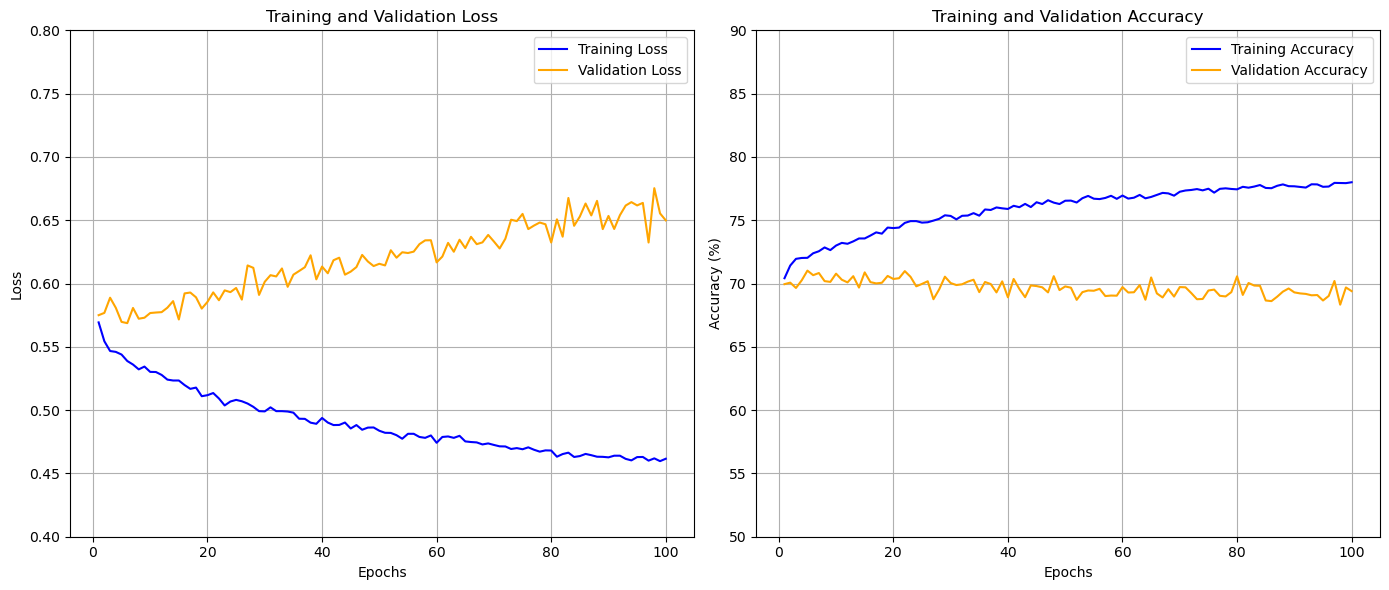

In [53]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS)

## Testing

In [54]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(dtype=torch.float32).to(device))
        predictions = (outputs.squeeze(1) >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [55]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100

print(f"Accuracy Score on test set: {test_acc_score:.2f} %")
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
print(f"AUC Score on test set: {test_auc_score:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(test_true_labels, test_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy Score on test set: 70.18 %
AUC Score on test set: 0.70
Precision: 0.7138
Recall: 0.6125
F1-Score: 0.6593

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73      5290
           1       0.71      0.61      0.66      4710

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000


Confusion Matrix:
[[4133 1157]
 [1825 2885]]


# Saving all metrics

In [56]:
# Training metrics
file_name = f"train-validation-metrics-{NUM_ITEMS}-{NUM_EPOCHS}.csv"
result_file = os.path.join(WORKING_DIR, 'output', 'train', MODE, f"{file_name}")

experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)

experiment_pl.write_csv(result_file)

In [57]:
# Test output
test_name = f"test-metrics-{NUM_ITEMS}-{NUM_EPOCHS}.csv"
test_file = os.path.join(WORKING_DIR, 'output', 'test', MODE,f"{test_name}")

test_results = {
    'test_acc'    : round(test_acc_score, 4),
    'test_auc'    : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(test_file)

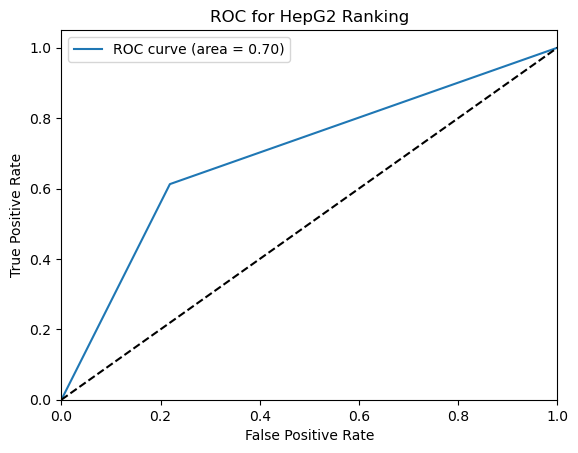

In [58]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Ranking')
plt.legend()

img_name = f"roc-{NUM_ITEMS}-{NUM_EPOCHS}.png"
plt.savefig(os.path.join(WORKING_DIR, 'output', 'img', 'roc', MODE, img_name))

plt.show()